# Análisis de viabilidad del TFM
En `df_fases_MES`tengo la **fase**, **máquina dominante**, y el **grupo/familia de esa máquina**. Con eso puedo montar un  cruce fase × máquina dentro de cada familia, ahi es donde vive la decisión de asignación.

Entonces, la elección real no es "esta fase fue a esta máquina" (eso siempre pasa). La elección existe cuando fases del mismo tipo pudieron ir a máquinas distintas de la misma familia.   
Por eso el análisis interesante es dentro de cada grupo: `¿las fases de una familia se reparten entre sus varias máquinas, o cada tipo de fase va siempre a la misma?`

In [76]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyarrow as pa
import pickle

# Construir el ratio real/teórico:

In [77]:
df_FASE_final = pd.read_parquet("res//procesed/df_FASE_final.parquet")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)   

display(df_FASE_final.sample(5))

,SmFaseUid,MaquinaDominante,smOrdenId,smMaterialId,smFaseNme,smOrdenNme,MinutosReal_efectivo,MinutosPreparacion_efectivo,MinutosProduccion_efectivo,MinutosReal_total,MinutosPreparacion_total,MinutosProduccion_total,dedicacion_media,n_imputaciones,IDMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo,IDMOTask,IDManufacturingOrder,Description,PreparationTime,ExecutionTime,TimeUnit,ProductEntry,MaterialExit,IDUsualTask,Quantity,ManualStartDate,RealEndDate,MESEntityId
15559,e4680539-9fb7-4c4a-870b-9d1cb4458586,TN09,OF2506209,PE1XNCX0127,TPP,Allonge coudée 103148655,142.916670,142.916670,0.00000,142.91667,142.91667,0.00000,50.000000,2,0bab3b63-5d31-4de3-85e2-89dc5a3e9bd5,TPP DOOSAN PUMA 240 (TPP) Torn C.N.C,27451f15-090c-42a6-82d6-98b7451db3db,TPU,Torns Puma (Taller COURES),ff03435d-1002-4f0f-ac50-9d405dcc135c,e35156d6-54f3-46fc-84f1-41d481985689,Mecanitzat al Torn Puma Petit,6.0,25.0,1.0,0.0,0.0,29783995-2f56-48be-9664-461e6f0b402a,5.0,2025-07-07 12:11:00.000,2025-07-10 00:00:00.000,e4680539-9fb7-4c4a-870b-9d1cb4458586
14817,da11e2d1-1c50-4c12-b101-84318524b616,TP02,OF2510645,PE1XA3X0331,MTP,COPPER PART Portaelectrodes MD639272S,20.526041,20.526041,0.00000,65.68333,65.68333,0.00000,15.625000,2,a045db52-b7d0-4011-b402-e7f63d5e4d3a,MTP IMSA MF800C-HD Màquina Taladres Profunds,7d29197b-e1a1-4c19-bf95-7fa3b96ed500,MTP,Màquines de Taladrat Profund,3b23d947-afae-4bab-b422-7f769be20201,0703b6e2-f7a1-42e5-8b1c-735f89c5ad64,Màquina de taladrat profund,5.0,10.0,1.0,0.0,0.0,4cfbb761-89c5-49c3-b68a-4a4024d85c8f,2.0,2025-11-04 13:19:00.000,2025-10-24 00:00:00.000,da11e2d1-1c50-4c12-b101-84318524b616
6932,6688fdeb-551c-4981-8c4c-618a9c0a2054,TN05,OF2602701,PA0XA2X0921,TMO,Verlängerung DS034679 (27011103500100101),199.816660,199.483330,0.33333,199.81666,199.48333,0.33333,50.000000,4,48e49bcb-1611-4e27-ba11-4cf376cd4a4e,MORI SEIKI NL2500 Torn C.N.C MORI SEIKI NL2500,6977175d-a2da-4925-a70f-fd0fcc4a2960,TCN,Torns Control Numèric,9914ba06-b020-4b47-b125-c90f804e4e94,ba5d0ecb-f4ee-488f-b5ca-1d87bc6f3ad6,Mecanització al TMO,40.0,16.0,1.0,0.0,0.0,e7285597-98fb-4216-aa59-b4775f4f7cfa,2.0,2026-04-27 23:02:00.000,2026-04-28 00:00:00.000,6688fdeb-551c-4981-8c4c-618a9c0a2054
7319,6c461dd3-bc6a-4a03-84d1-b61de48d42d1,TN09,OF2505993,PE2JNCX0006,DES,ALLONGE COUDÉE 103126372,64.983330,64.983330,0.00000,64.98333,64.98333,0.00000,50.000000,2,0bab3b63-5d31-4de3-85e2-89dc5a3e9bd5,TPP DOOSAN PUMA 240 (TPP) Torn C.N.C,27451f15-090c-42a6-82d6-98b7451db3db,TPU,Torns Puma (Taller COURES),ab9883c0-8278-4df9-a165-586ced2df9cf,ff4a0a3b-c152-4687-b897-aa4ce7eaa962,Cilindrar Desarrollo,5.0,9.0,1.0,0.0,0.0,c7043a00-2a5d-49ab-9c64-1713c31c17f9,1.0,2025-06-30 13:15:00.000,2025-06-25 00:00:00.000,6c461dd3-bc6a-4a03-84d1-b61de48d42d1
14287,d1edb55f-d278-480d-b134-78c087884ed1,TP02,OF2507574,PE2XNCX0120,MTP,Allonge coudée 103026849,7.525307,22.969621,0.00000,66.90000,204.20000,0.00000,5.624295,2,a045db52-b7d0-4011-b402-e7f63d5e4d3a,MTP IMSA MF800C-HD Màquina Taladres Profunds,7d29197b-e1a1-4c19-bf95-7fa3b96ed500,MTP,Màquines de Taladrat Profund,f2365713-7e77-4768-83cf-27a137f86c54,8ab44988-36b0-4e44-8eb3-f72b647b400e,Màquina de taladrat profund,5.0,10.0,1.0,0.0,0.0,4cfbb761-89c5-49c3-b68a-4a4024d85c8f,2.0,2025-07-31 13:31:00.000,2025-07-23 00:00:00.000,d1edb55f-d278-480d-b134-78c087884ed1


**Variables de tiempo**
- `MinutosRealNbr`, `MinutosPreparacionNbr`, `MinutosProduccionNbr`: dato original del MES, tiempo crudo (de reloj), sin corregir por dedicación. Vive a nivel de imputación individual.

- `MinutosReal_total`, `MinutosPreparacion_total`, `MinutosProduccion_total`: sumatorio del tiempo en crudo (de reloj) de todas las imputaciones de una misma fase.

- `MinutosReal_efectivo`, `MinutosPreparacion_efectivo`, `MinutosProduccion_efectivo`: Minutos reales totales de tiempo del MES corregido por el porcentaje de dedicación (`PorcentajeDedicacionNbr`) a nivel de imputación, y después sumado para todas las imputaciones de la fase.

MinutosReal_efectivo = MinutosRealNbr * PorcentajeDedicacionNbr / 100.

**Tiempos TEÓRICOS del ERP (lo que debería tardar):**     
- `PreparationTime` — teórico de preparación     
- `ExecutionTime` — teórico de ejecución/producción    

## Creación variable objetivo
La variable objetivo es el ratio entre el tiempo estimado (teórico) y el tiempo práctico (dedicado).

In [78]:
# --- Construcción del ratio sobre el tiempo EFECTIVO (teniendo en cuenta la dedicación) ---
df_FASE_final["tiempo_real_efectivo"] = df_FASE_final["MinutosReal_efectivo"]
df_FASE_final["tiempo_previsto"] = df_FASE_final["PreparationTime"] + df_FASE_final["ExecutionTime"]

df_FASE_final["ratio"] = df_FASE_final["tiempo_real_efectivo"] / df_FASE_final["tiempo_previsto"]

# --- Verificaciones ---
# ningún previsto en 0 (rompería la división)
print(f"Verificar Previsto = 0: {(df_FASE_final['tiempo_previsto'] == 0).sum()}")
# ninguna fase con tiempo real efectivo 0 (ratio = 0, sin señal)
print(f"Verificar  Real efectivo = 0 (ratio 0): {(df_FASE_final['tiempo_real_efectivo'] == 0).sum()}")

# distribución del ratio
print("\nDistribución del ratio (con tiempo efectivo):")
print(df_FASE_final["ratio"].describe())

display(df_FASE_final.sample(2))

Verificar Previsto = 0: 0
Verificar  Real efectivo = 0 (ratio 0): 0

Distribución del ratio (con tiempo efectivo):
count    14759.000000
mean         2.031888
std          2.538373
min          0.000114
25%          0.968617
50%          1.464444
75%          2.342942
max        150.616665
Name: ratio, dtype: float64


,SmFaseUid,MaquinaDominante,smOrdenId,smMaterialId,smFaseNme,smOrdenNme,MinutosReal_efectivo,MinutosPreparacion_efectivo,MinutosProduccion_efectivo,MinutosReal_total,MinutosPreparacion_total,MinutosProduccion_total,dedicacion_media,n_imputaciones,IDMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo,IDMOTask,IDManufacturingOrder,Description,PreparationTime,ExecutionTime,TimeUnit,ProductEntry,MaterialExit,IDUsualTask,Quantity,ManualStartDate,RealEndDate,MESEntityId,tiempo_real_efectivo,tiempo_previsto,ratio
7564,6f85278d-44d1-4c48-a08b-b58e4eaa6877,PH04,OF2506622,CODXA1X0039,CON,CONDUCTEUR*C45 MF180 IW7 190.200.040(B88352157...,27.80,0.00,27.8,27.80,0.00,27.8,50.0,2,d99a0600-181d-4875-8234-4f4b83d02b53,PH EUROMAC Digibend 720 Premsa Horitzontal,ccdc9993-5b02-4a48-a942-c4e7366bb499,CON,Premses Conformats,1721e031-8d4d-43cb-8637-8bf54aca5515,af9ddd8e-6446-4b8c-bb82-6ca74cde486a,Conformats,8.0,108.0,1.0,0.0,0.0,4a7a2acd-c093-4368-a714-2e2c4bf56317,18.0,2025-07-14 08:20:00.000,2025-07-10 00:00:00.000,6f85278d-44d1-4c48-a08b-b58e4eaa6877,27.80,116.0,0.239655
11186,a446de4d-8eae-4542-a9dc-669c29fb8b56,TP01,OF2512573,PE1XNCX0637,MTP,Elektrodenaufnahme F704501058029,20.15,20.15,0.0,20.15,20.15,0.0,50.0,2,4f696142-dc7b-46b8-b308-e4171cb8e3f2,MTP IXION Màquina Taladres Profunds,7d29197b-e1a1-4c19-bf95-7fa3b96ed500,MTP,Màquines de Taladrat Profund,709e2226-8ef7-4942-9210-ddba1554ab05,80276fac-bda1-4296-8108-b2783fdc25dd,Màquina de taladrat profund,5.0,12.0,1.0,0.0,0.0,4cfbb761-89c5-49c3-b68a-4a4024d85c8f,3.0,2026-01-19 10:27:00.000,2026-01-05 00:00:00.000,a446de4d-8eae-4542-a9dc-669c29fb8b56,20.15,17.0,1.185294


Los 54 con ratio = 0 (real efectivo nulo). Estas fases tienen teórico pero su tiempo real efectivo es 0 — probablemente fases cuyas imputaciones tenían todas dedicación 0, o tiempo real 0. Un ratio de 0 no significa "idoneidad perfecta", significa "sin dato de tiempo real". Hay que descartarlas, mismo argumento que los teóricos 0: sin real medible, no hay idoneidad.

In [79]:
antes = len(df_FASE_final)
df_FASE_final = df_FASE_final[df_FASE_final["tiempo_real_efectivo"] > 0]
print(f"Descartadas (ratio 0): {antes - len(df_FASE_final)}")
print(f"Total imputaciones: {len(df_FASE_final)}")

Descartadas (ratio 0): 0
Total imputaciones: 14759


El máximo de 150.61 es demasiado alto, físicamente es imposible como "mala idoneidad" real. Es ruido residual (solapamiento que la dedicación no capturó del todo, teóricos minúsculos mal cargados, o algún caso raro). 

In [80]:
# --- Exploración de ambas colas antes de cortar ---

# cola alta: cuántas fases con distintos umbrales
print("=== COLA ALTA (tardó mucho más que el teórico) ===")
for umbral in [5, 8, 10, 15, 20]:
    n = (df_FASE_final["ratio"] >= umbral).sum()
    print(f"  Ratio >= {umbral:>2}: {n:>4} fases ({n/len(df_FASE_final):.1%})")

# cola baja: cuántas fases sospechosamente rápidas
print("\n=== COLA BAJA (tardó mucho menos que el teórico) ===")
for umbral in [0.5, 0.3, 0.2, 0.1]:
    n = (df_FASE_final["ratio"] <= umbral).sum()
    print(f"  Ratio <= {umbral}: {n:>4} fases ({n/len(df_FASE_final):.1%})")

# percentiles para calibrar el corte con criterio estadístico
print("\n=== PERCENTILES ===")
for p in [0.01, 0.02, 0.05, 0.95, 0.98, 0.99]:
    print(f"  P{int(p*100):>2}: {df_FASE_final['ratio'].quantile(p):.3f}")

=== COLA ALTA (tardó mucho más que el teórico) ===
  Ratio >=  5:  800 fases (5.4%)
  Ratio >=  8:  261 fases (1.8%)
  Ratio >= 10:  154 fases (1.0%)
  Ratio >= 15:   64 fases (0.4%)
  Ratio >= 20:   32 fases (0.2%)

=== COLA BAJA (tardó mucho menos que el teórico) ===
  Ratio <= 0.5:  885 fases (6.0%)
  Ratio <= 0.3:  404 fases (2.7%)
  Ratio <= 0.2:  260 fases (1.8%)
  Ratio <= 0.1:  158 fases (1.1%)

=== PERCENTILES ===
  P 1: 0.092
  P 2: 0.229
  P 5: 0.448
  P95: 5.199
  P98: 7.521
  P99: 10.274


Como digo Outliers que son ruido (MES abierto, errores de registro, teóricos mal cargados) → hay que eliminarlos, contaminan el aprendizaje.

Dado que el ratio es una magnitud multiplicativa —expresa cuántas veces el tiempo real excede o queda por debajo del teórico—, el corte de valores atípicos se aplica sobre su logaritmo, donde la distribución resulta simétrica en torno a 0. Sobre log(ratio) se calcula el rango intercuartílico (IQR) y se definen como atípicos los valores fuera de [Q1 − 1,5·IQR, Q3 + 1,5·IQR]. Deshaciendo la transformación logarítmica, esto define un intervalo de valores admisibles de aproximadamente [0,26, 8,82].

In [81]:
log_ratio = np.log(df_FASE_final["ratio"])
q1, q3 = log_ratio.quantile([0.25, 0.75])
iqr = q3 - q1 
UMBRAL_BAJO = np.exp(q1 - 1.5 * iqr).round(3)
UMBRAL_ALTO = np.exp(q3 + 1.5 * iqr).round(3)

print(f"Umbrales: {UMBRAL_BAJO} (bajo) - {UMBRAL_ALTO} (alto)")

Umbrales: 0.257 (bajo) - 8.814 (alto)


In [82]:
antes = len(df_FASE_final)
alta = (df_FASE_final["ratio"] >= UMBRAL_ALTO).sum()
baja = (df_FASE_final["ratio"] <= UMBRAL_BAJO).sum()

df_FASE_final2 = df_FASE_final[(df_FASE_final["ratio"] > UMBRAL_BAJO) & (df_FASE_final["ratio"] < UMBRAL_ALTO)]

print(f"Descartadas cola alta (>= {UMBRAL_ALTO}): {alta}")
print(f"Descartadas cola baja (<= {UMBRAL_BAJO}): {baja}")
print(f"Total: {antes} → {len(df_FASE_final)}")

Descartadas cola alta (>= 8.814): 205
Descartadas cola baja (<= 0.257): 331
Total: 14759 → 14759


> Los cortes son asimétricos en interpretación, aunque parezcan simétricos en número. 
- El de arriba (≥9) quita "tardó absurdamente mucho", casi seguro tiempo muerto. 
- El de abajo (≤0.2) quita "tardó absurdamente poco", casi seguro teórico mal cargado o real incompleto. 
>Son dos problemas de datos distintos que dan la misma señal (ratio implausible), y ambos justifican el descarte.

In [83]:
print("Distribución del ratio:")
print(df_FASE_final2["ratio"].describe())

Distribución del ratio:
count    14223.000000
mean         1.886212
std          1.360957
min          0.257485
25%          0.998204
50%          1.474667
75%          2.317495
max          8.800000
Name: ratio, dtype: float64


Graficar la necesidad de emplear un umbral para los ratios

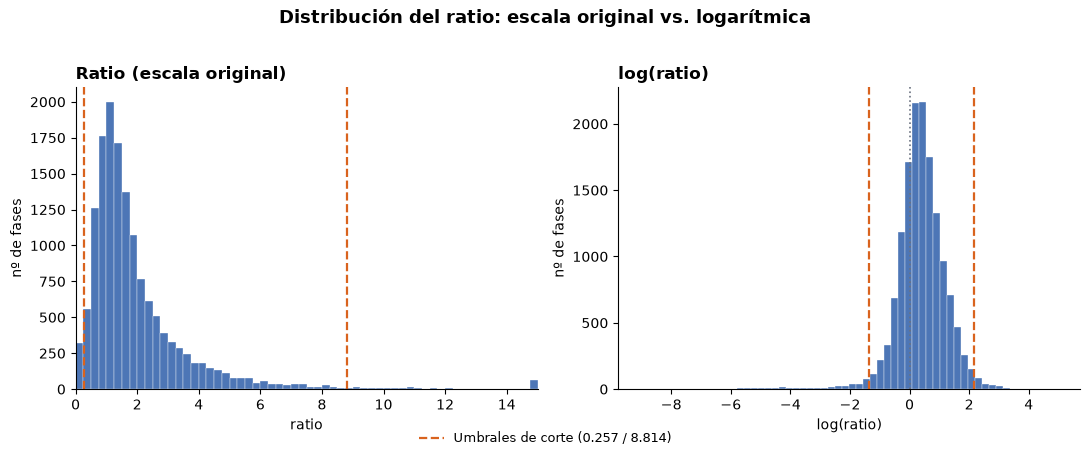

In [84]:
# ratio vs. log(ratio)
from matplotlib.lines import Line2D

log_ratio = np.log(df_FASE_final["ratio"])
log_bajo = np.log(UMBRAL_BAJO)
log_alto = np.log(UMBRAL_ALTO)

BLUE, ORANGE, GRAY = '#2E5EAA', '#D9631E', '#6B7280'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
ax.hist(df_FASE_final["ratio"].clip(upper=15), bins=60, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(UMBRAL_BAJO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.axvline(UMBRAL_ALTO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.set_title('Ratio (escala original)', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('ratio'); ax.set_ylabel('nº de fases')
ax.set_xlim(0, 15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax2 = axes[1]
ax2.hist(log_ratio, bins=60, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax2.axvline(0, color=GRAY, linewidth=1.2, linestyle=':')
ax2.axvline(log_bajo, color=ORANGE, linewidth=1.6, linestyle='--')
ax2.axvline(log_alto, color=ORANGE, linewidth=1.6, linestyle='--')
ax2.set_title('log(ratio)', fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('log(ratio)'); ax2.set_ylabel('nº de fases')
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.legend(handles=[Line2D([0], [0], color=ORANGE, lw=1.6, linestyle='--',
           label=f'Umbrales de corte ({UMBRAL_BAJO} / {UMBRAL_ALTO})')],
           loc='lower center', frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.suptitle('Distribución del ratio: escala original vs. logarítmica', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("res/procesed/graficos/03_ratio_vs_log_ratio.png", dpi=200, bbox_inches='tight')
plt.show()

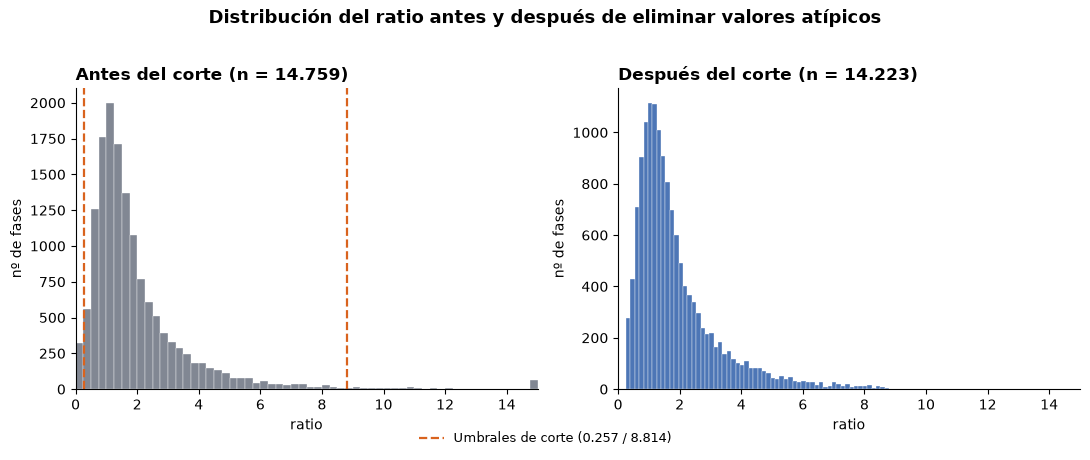

In [88]:
antes = df_FASE_final["ratio"]
despues = antes[(antes > UMBRAL_BAJO) & (antes < UMBRAL_ALTO)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
ax.hist(antes.clip(upper=15), bins=60, color=GRAY, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(UMBRAL_BAJO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.axvline(UMBRAL_ALTO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.set_title(f'Antes del corte (n = {len(antes):,})'.replace(',', '.'), fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('ratio'); ax.set_ylabel('nº de fases')
ax.set_xlim(0, 15)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax2 = axes[1]
ax2.hist(despues, bins=60, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax2.set_title(f'Después del corte (n = {len(despues):,})'.replace(',', '.'), fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('ratio'); ax2.set_ylabel('nº de fases')
ax2.set_xlim(0, 15)

for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.legend(handles=[Line2D([0], [0], color=ORANGE, lw=1.6, linestyle='--',
           label=f'Umbrales de corte ({UMBRAL_BAJO} / {UMBRAL_ALTO})')],
           loc='lower center', frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.suptitle('Distribución del ratio antes y después de eliminar valores atípicos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("res/procesed/graficos/05_antes_despues_corte.png", dpi=200, bbox_inches='tight')
plt.show()

Limpio:

In [85]:
df_FASE_final2 = df_FASE_final.drop(columns=["IDMOTask", "IDManufacturingOrder", "IDMaquina", "IDGrupo", "Description", "MinutosPreparacion_total", "MinutosProduccion_total", "MinutosReal_total", "MESEntityId", "ExecutionTime", "PreparationTime", "ManualStartDate", "RealEndDate"])
df_FASE_final2 = df_FASE_final2[["SmFaseUid", "MaquinaDominante", "NombreMaquina", "CodigoGrupo", "NombreGrupo", "smOrdenId", "smOrdenNme", "smFaseNme", "IDUsualTask", "smMaterialId", "Quantity", "tiempo_real_efectivo", "tiempo_teorico_total", "ratio", "ProductEntry", "MaterialExit", "n_imputaciones"]]
display(df_FASE_final2.sample(2))
print(df_FASE_final2[["Quantity", "tiempo_real_efectivo", "tiempo_teorico_total", "ratio"]].describe())

df_FASE_final2_id = df_FASE_final[["SmFaseUid", "IDMOTask", "IDManufacturingOrder", "IDMaquina", "IDGrupo"]]\
.rename(columns={
        "IDMOTask": "ID_Task_ERP",
        "IDManufacturingOrder": "ID_OF_ERP",
        })
display(df_FASE_final2_id.sample(2))

KeyError: "['tiempo_teorico_total'] not in index"

In [ ]:
#Inspecciono los peores tras la limpieza
#display(df_FASE_final.nlargest(20, "ratio")[["SmFaseUid", "MaquinaDominante", "NombreGrupo", "smFaseNme", "tiempo_real_efectivo", "tiempo_teorico_total", "ratio", "dedicacion_media", "n_imputaciones"]])

In [ ]:
df_FASE_final2.to_parquet("res//procesed/df_FASE_final2.parquet")

df_FASE_final2_id.to_parquet("res//procesed/df_FASE_final2_id.parquet")